In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import statsmodels.api as sm

from sklearn.preprocessing import power_transform

import pickle




In [2]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

pumpList = PCAData["Well Run"].unique()

complexVib = PCAData["ESP Vibration X"]+1j*PCAData["ESP Vibration Y"]

PCAData["VibMod"] = np.absolute(complexVib)

/tmp/ipykernel_147167/2553270337.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [19]:
n = [3, 5]

seeds = np.random.randint(low=19971215,high=20000728,size=30)

medianListR = np.array([]).astype(int)
medianListV = np.array([]).astype(int)
for seed in seeds:
    X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=PCAData)
    pumpList = PCAData["Well Run"].unique()

    data = PCAData["Radius"].loc[PCAData["Well_down"]==0]

    gmm = li.GaussianMixtureFit(data,n[0],seed)

    modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,li.StandardMarkovModel(n[0],seed,gmm))

    li.PostProcessing(modelRadius, PCAData, modelData,"Radius", "State Radius", totalLength, verbose=False)

    PCAData["State Radius"] = PCAData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n[0]))



    data = PCAData["VibMod"].loc[(PCAData["VibMod"]!=0) & (PCAData["Well_down"]==0)].apply(np.log1p)

    gmm = li.GaussianMixtureFit(data,n[1],seed)
         
    modelVib = li.HMMTrainer(X_train["VibMod"].apply(np.log1p),trainLength,li.StandardMarkovModel(n[1],seed,gmm))

    li.PostProcessing(modelVib, PCAData, modelData,"VibMod", "State Mod", totalLength, verbose=False)
    
    PCAData["State Mod"] = PCAData["State Mod"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))

    PCAData.loc[(PCAData["VibMod"]==0) & (PCAData["Well_down"]==0),"State Mod"] = 5

    medianListR_G = np.array([])
    medianListV_G = np.array([])

    for pump in pumpList:
        pumpData = PCAData.loc[(PCAData["Well Run"]==pump) & (PCAData["Well_down"]==0) ]#.copy()
        last = pumpData.shape[0]
        pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
        pumpMedianV = pumpData.loc[pumpData.index[last-24:last-1],"State Mod"].median()
        medianListR_G = np.append(medianListR_G,pumpMedianR)
        medianListV_G = np.append(medianListV_G,pumpMedianV)

    medianListR = np.concat((medianListR, medianListR_G))
    medianListV = np.concat((medianListV, medianListV_G))

In [33]:
saveA = np.array([medianListR,medianListV]).T

Text(0.5, 1.0, 'Histograma da média de Persistência de Estados - Energia PCA')

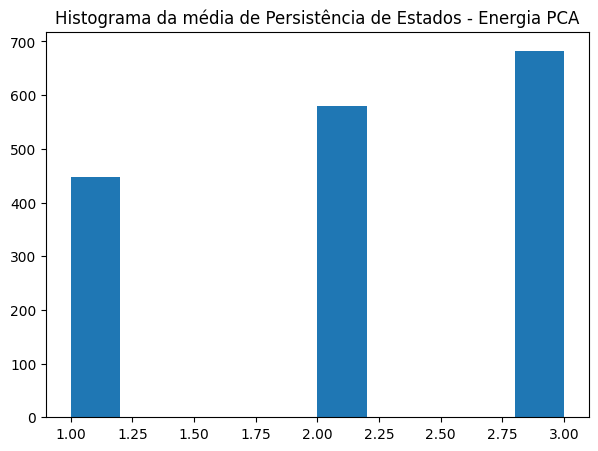

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(medianListR)


Text(0.5, 1.0, 'Histograma da média de Persistência de Estados - Módulo da Vibração')

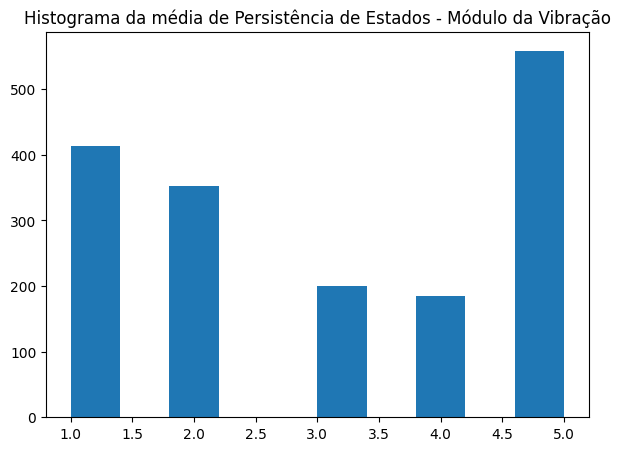

In [21]:
plt.figure(figsize=(7,5))
plt.hist(medianListV)
plt.title("Histograma da média de Persistência de Estados - Módulo da Vibração")